# Programming Assignment 3

**Colab Free Tier has pretty strict GPU usage time limits**

**I would HIGHLY recommend doing all development on the CPU runtime instance (you can change this by clicking the dropdown arrow next to Connect (top right) --> Change Runtime Type --> CPU or T4), and then only switching to the T4 runtime (T4 is an Nvidia GPU), when you are ready to actually train the model**

## 1. Setup

Installing packages and downloading Atari environments

In [1]:
pip install ale-py

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 73.6 MB 964 kB/s eta 0:00:013
     |████████████████████████████████| 1.9 MB 13.9 MB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 5.6 MB/s eta 0:00:01
     |████████████████████████████████| 6.3 MB 39.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 43.3 MB/s eta 0:00:01
     |████████████████████████████████| 200 kB 74.9 MB/s eta 0:00:01
     |████████████████████████████████| 536 kB 22.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install "gymnasium[atari,other]" ale-py "autorom[accept-rom-license]" moviepy "imageio[ffmpeg]"

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install git+https://github.com/MLivanos/colabgymrender.git

  Cloning https://github.com/MLivanos/colabgymrender.git to /private/var/folders/sv/0kxycdhn70x_kdsd2hrfp03c0000gn/T/pip-req-build-f2fef6m7
  Running command git clone --filter=blob:none --quiet https://github.com/MLivanos/colabgymrender.git /private/var/folders/sv/0kxycdhn70x_kdsd2hrfp03c0000gn/T/pip-req-build-f2fef6m7
  Resolved https://github.com/MLivanos/colabgymrender.git to commit 8526ad9deec50a445e63b8faf2b894d3b0cd7cd2
  Preparing metadata (setup.py) ... done

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Visualize

In [4]:
import base64
import os
from IPython.display import HTML, display

def render_mp4_video(video_folder):
    """Finds the first mp4 in the folder and displays it in the notebook."""
    video_files = [f for f in os.listdir(video_folder) if f.endswith('.mp4')]

    if not video_files:
        print("No video found! Make sure the episode actually finished and triggered the recorder.")
        return

    # Pick the most recent video
    video_path = os.path.join(video_folder, sorted(video_files)[-1])

    video_file = open(video_path, "rb").read()
    encoded = base64.b64encode(video_file).decode("ascii")

    html_code = f"""
    <video width="600" height="400" controls>
        <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
    </video>
    """
    display(HTML(html_code))

### Demo of environment

In [5]:
import gymnasium as gym
import ale_py

# 1. Setup Environment
gym.register_envs(ale_py)
env = gym.make("ALE/MsPacman-v5", render_mode="rgb_array")

# 2. Wrap for recording (recording the first episode)
video_path = "./saved-videos"
env = gym.wrappers.RecordVideo(
    env,
    video_folder=video_path,
    episode_trigger=lambda x: x == 0,
    name_prefix="pacman-run"
)

# 3. Run a quick episode
obs, info = env.reset()
done = False
while not done:
    action = env.action_space.sample() # Random actions
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.close()

# 4. SHOW THE VIDEO IN THE CELL
render_mp4_video(video_path)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/Users/marqlott/Library/Python/3.9/lib/python/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/marqlott/Downloads/PA#3/saved-videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## Deep Q-Learning

### 2.1 Environment and Model Setup

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os
from collections import deque
import gymnasium as gym
import ale_py
import matplotlib.pyplot as plt
import time

# Gymnasium v1.0.0+ standard imports
from gymnasium.wrappers import (
    AtariPreprocessing,
    FrameStackObservation,
    TransformObservation,
    RecordVideo
)

def make_lite_env(env_id, render_mode=None, is_eval=False):
    """
    Standardized Atari Environment Factory.

    This function applies the 'Atari Preprocessing' suite which is essential
    for training stability. It reduces memory usage, simplifies the input
    space, and provides the agent with 'vision' of movement.
    """

    # 1. Registration: Ensures the ALE (Arcade Learning Environment) environments
    # are recognized by Gymnasium.
    gym.register_envs(ale_py)

    # 2. Base Env: Creates the raw environment. 'frameskip=1' is set here because
    # we handle skipping manually in the AtariPreprocessing wrapper for finer control.
    env = gym.make(env_id, render_mode=render_mode, frameskip=1)

    # 3. AtariPreprocessing: The "Workhorse" wrapper.
    # - screen_size=84: Downscales from ~210x160 to 84x84 (drastic speedup).
    # - grayscale_obs: Removes color (RGB) to reduce input channels from 3 to 1.
    # - frame_skip=4: The agent only 'sees' every 4th frame. The chosen action
    #   is repeated for the skipped frames. This speeds up training 4x.
    # - terminal_on_life_loss: CRITICAL FOR TRAINING. In many Atari games,
    #   losing a life doesn't reset the game, but we want the agent to treat
    #   it as a 'Failure' state to learn survival. During evaluation (is_eval),
    #   we set this to False to see the agent's full 3-life performance.
    env = AtariPreprocessing(
        env,
        screen_size=84,
        grayscale_obs=True,
        frame_skip=4,
        terminal_on_life_loss=not is_eval
    )

    # 4. FrameStack: Adds temporal context (Time).
    # A single grayscale frame is just a still image; the agent can't tell if
    # Pac-Man is moving left or right. By stacking the last 4 frames, the CNN
    # can see 'velocity' and 'direction' of ghosts and players.
    # Input shape becomes: (4, 84, 84)
    env = FrameStackObservation(env, stack_size=4)

    new_obs_space = gym.spaces.Box(
            low=0, high=255, shape=env.observation_space.shape, dtype=np.uint8
        )
    env = TransformObservation(
        env,
        lambda obs: np.array(obs).astype(np.uint8),
        new_obs_space
    )

    return env

Mount the Google Drive

In case the runtime disconnected, temporary files lose.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Plot the loss and reward

In [9]:
def plot_metrics(rewards_history, losses, reward_window=20):
    """
    X-axis = Training Steps (matching console logs)
    Y-axis = Episode Rewards
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    if len(rewards_history) > 0:
        # 1. Convert to numpy array: col 0 is Steps, col 1 is Reward
        data = np.array(rewards_history)
        steps = data[:, 0]
        rewards = data[:, 1]

        # 2. Reward Plot
        ax[0].plot(steps, rewards, label='Episode Score', alpha=0.3, color='dodgerblue')

        # Calculate moving average
        if len(rewards) > reward_window:
            ma = np.convolve(rewards, np.ones(reward_window)/reward_window, mode='valid')
            ma_steps = steps[reward_window-1:]
            ax[0].plot(ma_steps, ma, label=f'{reward_window}-Ep Moving Avg', color='red', linewidth=2)

        ax[0].set_title("Ms. Pacman Performance")
        ax[0].set_xlabel("Total Steps")
        ax[0].set_ylabel("Reward")
        ax[0].legend()
        ax[0].grid(True, alpha=0.3)

    # 3. Loss Plot (Logged per optimization step)
    if len(losses) > 100:
        ma_loss = np.convolve(losses, np.ones(100)/100, mode='valid')
        ax[1].plot(ma_loss, color='forestgreen', label='Loss Trend')
    else:
        ax[1].plot(losses, color='forestgreen', alpha=0.5)

    ax[1].set_title("Training Loss (Internal Error)")
    ax[1].set_xlabel("Optimization Steps")
    ax[1].set_ylabel("MSE Loss")
    ax[1].set_yscale('log') # Log scale handles the huge drops in loss better
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_progress.png')
    plt.show()

### 2.2 Q Network

In [10]:
class QNetwork(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(4, 16, 8, stride=4),  # (4, 84, 84) -> (16, 20, 20)
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2), # (16, 20, 20) -> (32, 9, 9)
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 9 * 9, 256),
            nn.ReLU(),
            nn.Linear(256, n_actions)
        )

    def forward(self, x):
      x = x.float() / 255.0
      return self.network(x)

In [45]:
checkpoint = torch.load("pacman_final_dqn_v2(1008).pth", map_location=DEVICE)
q_net.load_state_dict(checkpoint['model_state_dict'])
print("Loaded saved model")

Loaded saved model


### 2.3 Configuaration and hyperparameters

In [46]:
# --- SYSTEM & ENVIRONMENT ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Hardware: GPU if available, else CPU
ENV_ID = "ALE/MsPacman-v5"                                           # Game: Ms. Pacman (v5 includes sticky actions)

# --- HYPERPARAMETERS ---
LR = 2.5e-4         # NOTE: CHANGED from 1e-4 to 2.5e-4
BATCH_SIZE = 32      # Minibatch: Number of transitions used per training step
GAMMA = 0.99         # Discount Factor: Importance of future vs. immediate rewards

# --- TRAINING SCALE ---
MEMORY_SIZE = 50000  # NOTE: CHANGED from 10000 to 50000
TOTAL_STEPS = 500000 # Training Duration: Total frames the agent will experience

CHECKPOINT_PATH = "pacman_dqn_checkpoint.pth" # Save File: Path for model weights
# TODO Change to Google drive path if needed. "/content/drive/My Drive/" + CHECKPOINT_PATH

history_rewards = []  # Total reward per episode/life
history_loss = []     # MSE loss per optimization step
current_episode_reward = 0


### 2.4 Initialization

In [47]:
env = make_lite_env(ENV_ID, is_eval=False) # Change is_eval to True and the reward in the training loop to train on all three lives.
q_net = QNetwork(env.action_space.n).to(DEVICE)
target_net = QNetwork(env.action_space.n).to(DEVICE)
optimizer = optim.Adam(q_net.parameters(), lr=LR)
memory = deque(maxlen=MEMORY_SIZE)

start_step = 0
resume_from_checkpoint = True # Set to True to resume from disconnected training. You can not load any other models for training.

if resume_from_checkpoint and os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    q_net.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_step = checkpoint['step']
    # Load history if you want to keep plots continuous
    history_rewards = checkpoint.get('history_rewards', [])
    history_loss = checkpoint.get('history_loss', [])
    print(f"Resuming from step {start_step}")

target_net.load_state_dict(q_net.state_dict())
obs, _ = env.reset()

Resuming from step 490000


### 2.5 Training Loop

In [44]:
start_time = time.time()
print(f"Starting training on {DEVICE}...")
for step in range(start_step, TOTAL_STEPS):
    # NOTE: CHANGED from max(0.1, 1.0 - (step / (TOTAL_STEPS * 0.8))) to max(0.05, 1.0 - (step / (TOTAL_STEPS * 0.4)))
    epsilon = max(0.05, 1.0 - (step / (TOTAL_STEPS * 0.4)))

    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            state_t = torch.FloatTensor(np.array([obs])).to(DEVICE)
            # TODO Code: Get action
            action = q_net(state_t).argmax(dim=1).item()

    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    current_episode_reward += reward
    memory.append((obs, action, reward, next_obs, terminated))
    obs = next_obs

    if done:
        history_rewards.append([step, current_episode_reward])
        current_episode_reward = 0
        obs, _ = env.reset()

    if len(memory) > BATCH_SIZE:
        # TODO Code: Random sample a batch from reply buffer
        batch = random.sample(memory, BATCH_SIZE)

        s, a, r, ns, d = zip(*batch)
        s = torch.from_numpy(np.array(s)).to(DEVICE)
        ns = torch.from_numpy(np.array(ns)).to(DEVICE)

        a = torch.LongTensor(a).to(DEVICE).unsqueeze(1)
        r = torch.FloatTensor(r).to(DEVICE)
        d = torch.FloatTensor(d).to(DEVICE)

        # Now when you call q_net(s), the normalization happens on GPU!
        current_q = q_net(s).gather(1, a).squeeze()

        with torch.no_grad():
            next_q = target_net(ns).max(1)[0]
            # TODO Code: Get Q Value, Update of target_q
            target_q = r + (1 - d) * GAMMA * next_q

        # TODO Code: Loss function on current_q and target_q
        loss = nn.MSELoss()(current_q, target_q)
        optimizer.zero_grad()
        loss.backward()
        
        # NOTE: ADDED gradient clipping for training stability
        torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10)
        # End gradient clipping addition
        
        optimizer.step()
        history_loss.append(loss.item())

    if step % 10000 == 0 and step > start_step:
        target_net.load_state_dict(q_net.state_dict())
        torch.save({
            'step': step,
            'model_state_dict': q_net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history_rewards': history_rewards,
            'history_loss': history_loss
        }, CHECKPOINT_PATH)

        # Extract just the rewards (column 1) from the last 20 entries
        last_rewards = [r[1] for r in history_rewards[-20:]]
        avg_reward = np.mean(last_rewards) if last_rewards else 0
        print(f"Step {step} | Eps: {epsilon:.2f} | Avg Reward (Last 20): {avg_reward:.1f}")

env.close()

# Calculate and display execution time
end_time = time.time()
total_duration = end_time - start_time
minutes = int(total_duration // 60)
seconds = int(total_duration % 60)

print(f"\nTraining Complete!")
print(f"Total Training Time: {minutes}m {seconds}s")

Starting training on cpu...
Step 440000 | Eps: 0.05 | Avg Reward (Last 20): 610.0
Step 450000 | Eps: 0.05 | Avg Reward (Last 20): 622.0
Step 460000 | Eps: 0.05 | Avg Reward (Last 20): 769.0
Step 470000 | Eps: 0.05 | Avg Reward (Last 20): 809.0
Step 480000 | Eps: 0.05 | Avg Reward (Last 20): 686.5
Step 490000 | Eps: 0.05 | Avg Reward (Last 20): 720.0

Training Complete!
Total Training Time: 48m 23s


### 2.6 Training Results

Plot

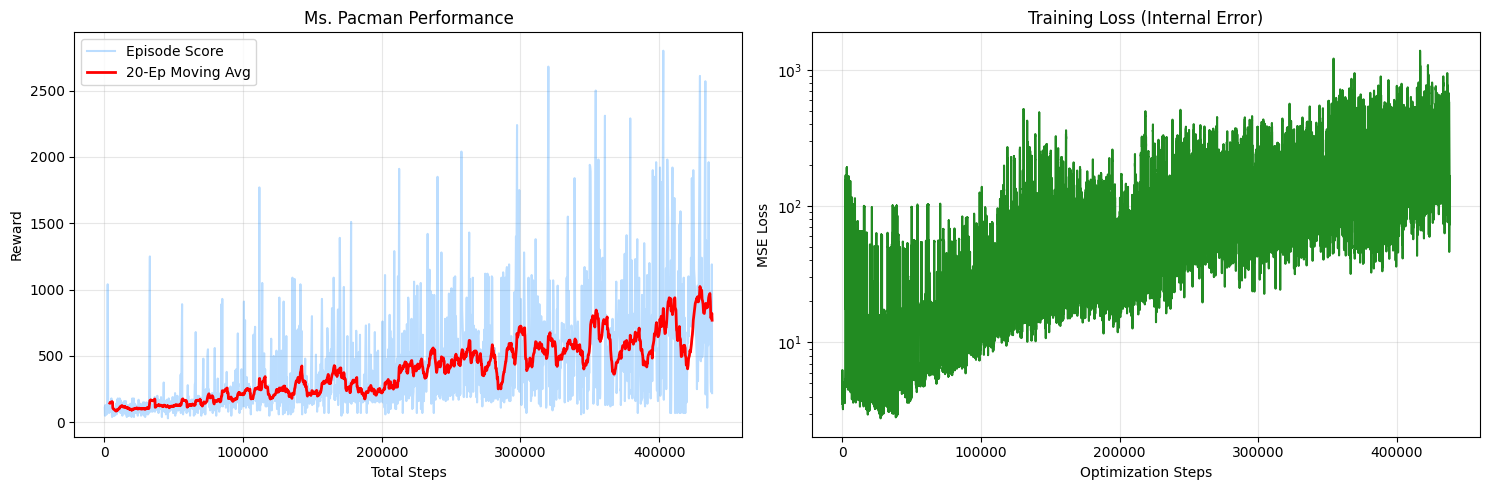

In [34]:
# Call the plot function
# This uses the history collected during the loop
plot_metrics(history_rewards, history_loss)

Game Video

In [40]:
eval_env = make_lite_env(ENV_ID, render_mode="rgb_array", is_eval=True)
video_path = "./pacman_trained"
eval_env = RecordVideo(eval_env, video_folder=video_path, name_prefix="dqn-pacman", episode_trigger=lambda x: True)

obs, _ = eval_env.reset()
done = False
total_eval_score = 0  # <--- NEW: Score tracker

while not done:
    with torch.no_grad():
        state_t = torch.FloatTensor(np.array([obs])).to(DEVICE)
        action = q_net(state_t).argmax().item()

    obs, reward, terminated, truncated, _ = eval_env.step(action)
    total_eval_score += reward  # <--- Accumulate score
    done = terminated or truncated

print(f"--- Evaluation Complete ---")
print(f"Final Game Score: {total_eval_score}") # <--- Print the result
eval_env.close()

render_mp4_video(video_path)

--- Evaluation Complete ---
Final Game Score: 1320.0


### 2.7 Save the model if needed

In [41]:
# --- After the training loop finishes ---

final_model_path = "pacman_final_dqn.pth" # Change to Google Drive path if needed

# 1. Save the model weights and training metadata
save_data = {
    'model_state_dict': q_net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'total_steps': TOTAL_STEPS,
    'epsilon_final': epsilon,
    'env_id': ENV_ID
}

torch.save(save_data, final_model_path)
print(f"\n✅ Final model saved to {final_model_path}")


✅ Final model saved to pacman_final_dqn.pth


## 3. Bonus Points Algorithm

Game score should be higher than 1500 to be eligible for bonus points.

In [ ]:
# --- BONUS TRAINING (from scratch, no pre-loaded Q-network) ---
BONUS_ENV_ID = ENV_ID
BONUS_TOTAL_STEPS = 2_500_000  # You may increase up to 2_500_000 for bonus attempts
BONUS_MEMORY_SIZE = 200_000
BONUS_BATCH_SIZE = 32
BONUS_GAMMA = 0.995
BONUS_LR_START = 3e-4
BONUS_LR_END = 5e-6
BONUS_EPS_MIN = 0.02
BONUS_EPS_DECAY_FRACTION = 0.6
BONUS_TARGET_SYNC = 5_000
BONUS_CHECKPOINT_PATH = "pacman_bonus_checkpoint.pth"
BONUS_BEST_PATH = "pacman_bonus_best.pth"

# Resume is ONLY for interrupted sessions of this same bonus run. 
BONUS_RESUME_FROM_CHECKPOINT = True

bonus_env = make_lite_env(BONUS_ENV_ID, is_eval=False)
bonus_q_net = QNetwork(bonus_env.action_space.n).to(DEVICE)
bonus_target_net = QNetwork(bonus_env.action_space.n).to(DEVICE)
bonus_target_net.load_state_dict(bonus_q_net.state_dict())
bonus_optimizer = optim.Adam(bonus_q_net.parameters(), lr=BONUS_LR_START)
bonus_memory = deque(maxlen=BONUS_MEMORY_SIZE)

bonus_history_rewards = []
bonus_history_loss = []
bonus_episode_reward = 0
bonus_best_avg_reward = -float("inf")
bonus_start_step = 0

if BONUS_RESUME_FROM_CHECKPOINT and os.path.exists(BONUS_CHECKPOINT_PATH):
    bonus_checkpoint = torch.load(BONUS_CHECKPOINT_PATH, map_location=DEVICE)
    bonus_q_net.load_state_dict(bonus_checkpoint["model_state_dict"])
    bonus_target_net.load_state_dict(bonus_q_net.state_dict())
    bonus_optimizer.load_state_dict(bonus_checkpoint["optimizer_state_dict"])
    bonus_start_step = bonus_checkpoint.get("step", 0)
    bonus_history_rewards = bonus_checkpoint.get("history_rewards", [])
    bonus_history_loss = bonus_checkpoint.get("history_loss", [])
    bonus_best_avg_reward = bonus_checkpoint.get("best_avg_reward", -float("inf"))
    print(f"[BONUS] Resuming interrupted bonus run from step {bonus_start_step}")

bonus_obs, _ = bonus_env.reset()
bonus_start_time = time.time()
step = bonus_start_step

print(f"Starting BONUS training on {DEVICE} for up to {BONUS_TOTAL_STEPS} steps...")

try:
    for step in range(bonus_start_step, BONUS_TOTAL_STEPS):
        epsilon = max(BONUS_EPS_MIN, 1.0 - (step / (BONUS_TOTAL_STEPS * BONUS_EPS_DECAY_FRACTION)))

        # Linear LR decay for stability late in training
        lr = BONUS_LR_END + (BONUS_LR_START - BONUS_LR_END) * max(
            0.0, 1.0 - (step / (BONUS_TOTAL_STEPS * 0.8))
        )
        for param_group in bonus_optimizer.param_groups:
            param_group["lr"] = lr

        if random.random() < epsilon:
            action = bonus_env.action_space.sample()
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(np.array([bonus_obs])).to(DEVICE)
                action = bonus_q_net(state_t).argmax(dim=1).item()

        next_obs, reward, terminated, truncated, _ = bonus_env.step(action)
        done = terminated or truncated
        bonus_episode_reward += reward

        bonus_memory.append((bonus_obs, action, reward, next_obs, terminated))
        bonus_obs = next_obs

        if done:
            bonus_history_rewards.append([step, bonus_episode_reward])
            bonus_episode_reward = 0
            bonus_obs, _ = bonus_env.reset()

        if len(bonus_memory) > BONUS_BATCH_SIZE:
            batch = random.sample(bonus_memory, BONUS_BATCH_SIZE)
            s, a, r, ns, d = zip(*batch)

            s = torch.from_numpy(np.array(s)).to(DEVICE)
            ns = torch.from_numpy(np.array(ns)).to(DEVICE)
            a = torch.LongTensor(a).to(DEVICE).unsqueeze(1)
            r = torch.FloatTensor(r).to(DEVICE)
            d = torch.FloatTensor(d).to(DEVICE)

            current_q = bonus_q_net(s).gather(1, a).squeeze()

            with torch.no_grad():
                # Double DQN target: action from online net, value from target net
                next_actions = bonus_q_net(ns).argmax(dim=1, keepdim=True)
                next_q = bonus_target_net(ns).gather(1, next_actions).squeeze(1)
                target_q = r + (1 - d) * BONUS_GAMMA * next_q

            loss = nn.SmoothL1Loss()(current_q, target_q)
            bonus_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bonus_q_net.parameters(), max_norm=10)
            bonus_optimizer.step()
            bonus_history_loss.append(loss.item())

        if step % BONUS_TARGET_SYNC == 0 and step > 0:
            bonus_target_net.load_state_dict(bonus_q_net.state_dict())

        if step % 10_000 == 0 and step > 0:
            last_rewards = [x[1] for x in bonus_history_rewards[-20:]]
            avg_reward = np.mean(last_rewards) if last_rewards else 0.0
            print(f"[BONUS] Step {step} | Eps: {epsilon:.2f} | LR: {lr:.6f} | Avg Reward (Last 20): {avg_reward:.1f}")

            torch.save(
                {
                    "step": step,
                    "model_state_dict": bonus_q_net.state_dict(),
                    "optimizer_state_dict": bonus_optimizer.state_dict(),
                    "history_rewards": bonus_history_rewards,
                    "history_loss": bonus_history_loss,
                    "best_avg_reward": bonus_best_avg_reward,
                },
                BONUS_CHECKPOINT_PATH,
            )

            if avg_reward > bonus_best_avg_reward:
                bonus_best_avg_reward = avg_reward
                torch.save(
                    {
                        "step": step,
                        "avg_reward": avg_reward,
                        "model_state_dict": bonus_q_net.state_dict(),
                    },
                    BONUS_BEST_PATH,
                )
                print(f"[BONUS] New best checkpoint saved at step {step} with avg reward {avg_reward:.1f}")

except KeyboardInterrupt:
    print("[BONUS] Training interrupted by user.")

finally:
    bonus_env.close()
    torch.save(
        {
            "step": step,
            "model_state_dict": bonus_q_net.state_dict(),
            "optimizer_state_dict": bonus_optimizer.state_dict(),
            "history_rewards": bonus_history_rewards,
            "history_loss": bonus_history_loss,
            "best_avg_reward": bonus_best_avg_reward,
        },
        BONUS_CHECKPOINT_PATH,
    )

bonus_end_time = time.time()
bonus_minutes = int((bonus_end_time - bonus_start_time) // 60)
bonus_seconds = int((bonus_end_time - bonus_start_time) % 60)
print(f"[BONUS] Training complete. Time: {bonus_minutes}m {bonus_seconds}s")
print(f"[BONUS] Latest checkpoint: {BONUS_CHECKPOINT_PATH}")
print(f"[BONUS] Best checkpoint:   {BONUS_BEST_PATH}")

Print the reward and score. Show and download the video.

In [ ]:
# --- BONUS EVALUATION + VIDEO ---
bonus_video_path = "./pacman_bonus_video"
bonus_eval_env = make_lite_env(BONUS_ENV_ID, render_mode="rgb_array", is_eval=True)
bonus_eval_env = RecordVideo(
    bonus_eval_env,
    video_folder=bonus_video_path,
    name_prefix="bonus-pacman",
    episode_trigger=lambda x: True,
)

if os.path.exists(BONUS_BEST_PATH):
    best_checkpoint = torch.load(BONUS_BEST_PATH, map_location=DEVICE)
    bonus_q_net.load_state_dict(best_checkpoint["model_state_dict"])
    print(
        f"Loaded BONUS best model from step {best_checkpoint['step']} "
        f"with avg reward {best_checkpoint['avg_reward']:.1f}"
    )
else:
    print("BONUS best checkpoint not found. Evaluating current in-memory bonus model.")

obs, _ = bonus_eval_env.reset()
done = False
bonus_total_eval_score = 0

while not done:
    with torch.no_grad():
        state_t = torch.FloatTensor(np.array([obs])).to(DEVICE)
        action = bonus_q_net(state_t).argmax(dim=1).item()

    obs, reward, terminated, truncated, _ = bonus_eval_env.step(action)
    bonus_total_eval_score += reward
    done = terminated or truncated

bonus_eval_env.close()

print("--- BONUS Evaluation Complete ---")
print(f"BONUS Final Game Score: {bonus_total_eval_score}")
if bonus_total_eval_score >= 1500:
    print("Eligible score threshold met for bonus consideration (>=1500).")
else:
    print("Bonus threshold not met yet (need >=1500).")

# Save final evaluated bonus model snapshot
bonus_final_path = "pacman_bonus_final.pth"
torch.save(
    {
        "model_state_dict": bonus_q_net.state_dict(),
        "score": bonus_total_eval_score,
    },
    bonus_final_path,
)
print(f"BONUS final model saved to {bonus_final_path}")

render_mp4_video(bonus_video_path)

# Optional: plot bonus training curves if this kernel has training history
if "bonus_history_rewards" in globals() and "bonus_history_loss" in globals() and len(bonus_history_rewards) > 0:
    plot_metrics(bonus_history_rewards, bonus_history_loss)
